In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [59]:
train=pd.read_csv(r"C:\Users\DELL\Downloads\rossmann-store-sales\train.csv", low_memory=False)

### INFORMATION ABOUT TRAIN DATAFRAME
#### Promo - indicates whether a store is running a promo on that day
#### StateHoliday - indicates a state holiday. Normally all stores, with few exceptions, are closed on state holidays. Note that all schools are closed on public holidays and weekends. a = public holiday, b = Easter holiday, c = Christmas, 0 = None

In [60]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [61]:
train.tail()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1
1017208,1115,2,2013-01-01,0,0,0,0,a,1


In [62]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [63]:
train.sample(n=50)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
354324,167,3,2014-08-27,7234,987,1,0,0,1
883209,915,3,2013-05-01,0,0,0,1,a,0
277726,252,1,2014-11-17,7979,665,1,0,0,0
176096,1042,2,2015-02-24,3065,485,1,0,0,0
936242,428,4,2013-03-14,4066,386,1,0,0,0
215835,641,1,2015-01-19,4263,464,1,0,0,0
984515,756,3,2013-01-30,12391,1686,1,0,0,0
300368,484,5,2014-10-24,8117,812,1,1,0,1
886575,936,7,2013-04-28,0,0,0,0,0,0
523530,266,3,2014-03-19,5007,635,1,1,0,0


In [64]:
train.isnull().sum()

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

In [65]:
train.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00


In [66]:
train.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday'],
      dtype='object')

### 1. Sales column analysis

In [67]:
train["Sales"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1017209 entries, 0 to 1017208
Series name: Sales
Non-Null Count    Dtype
--------------    -----
1017209 non-null  int64
dtypes: int64(1)
memory usage: 7.8 MB


In [68]:
train["Sales"].describe()

count    1.017209e+06
mean     5.773819e+03
std      3.849926e+03
min      0.000000e+00
25%      3.727000e+03
50%      5.744000e+03
75%      7.856000e+03
max      4.155100e+04
Name: Sales, dtype: float64

In [69]:
train["Sales"].skew()
## Skewness of the Sales column is 0.64, which indicates a moderate positive skew. This means most sales values 
#are concentrated in the lower to middle range, while a small number of observations have much higher sales, 
#creating a right tail in the distribution.

np.float64(0.6414596158103795)

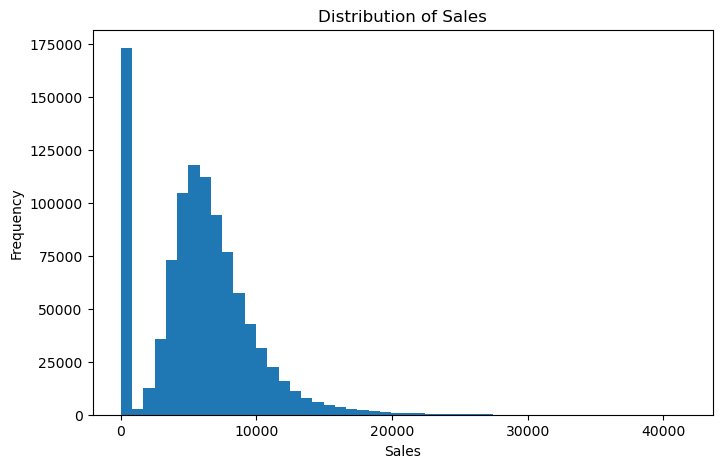

In [70]:
plt.figure(figsize=(8,5))
plt.hist(train["Sales"], bins=50)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

### Why sales=0 have this much value ?
### Because store was closeed maximum times

In [71]:
train[train["Sales"] == 0]["StateHoliday"].value_counts()

StateHoliday
0    142731
a     19566
b      6545
c      4029
Name: count, dtype: int64

In [72]:
train[train["Sales"] == 0]["Open"].value_counts()

Open
0    172817
1        54
Name: count, dtype: int64

 ### Observation

#### - A significant spike was observed at Sales = 0.
#### - Investigation revealed that almost all zero sales occurred when the store was closed (Open = 0).
#### - Only 54 records had Open = 1 and Sales = 0, which will be investigated during the data cleaning stage.

In [73]:
train[(train["Sales"] == 0) & (train["Open"] == 1)]["StateHoliday"].value_counts()

StateHoliday
0    54
Name: count, dtype: int64

In [74]:
train["Open"].value_counts(normalize=True) * 100

Open
1    83.010669
0    16.989331
Name: proportion, dtype: float64

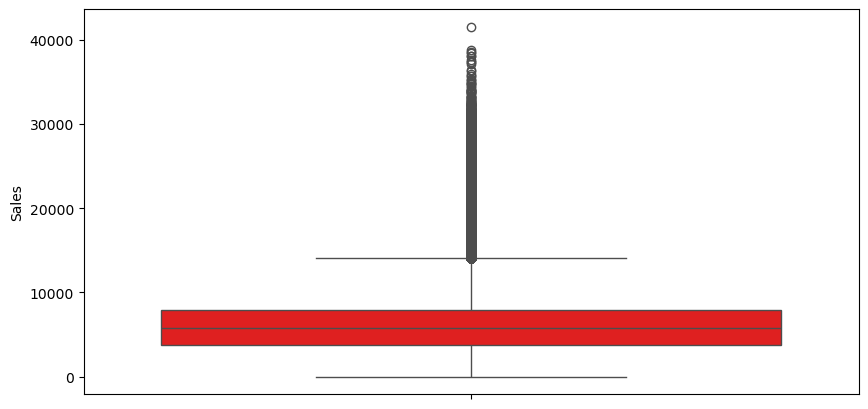

In [75]:
plt.figure(figsize=(10,5))
sns.boxplot(data=train['Sales'],color='r')
plt.show()

In [76]:
train["Sales"].quantile([0.25, 0.5, 0.75, 0.95, 0.99])

0.25     3727.0
0.50     5744.0
0.75     7856.0
0.95    12137.0
0.99    17160.0
Name: Sales, dtype: float64

In [77]:
train["Sales"].max()

41551

In [78]:
train[train["Sales"]==train["Sales"].max()]

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
44393,909,1,2015-06-22,41551,1721,1,0,0,0


## 2.Store column Analysis

In [79]:
train["Store"].unique()

array([   1,    2,    3, ..., 1113, 1114, 1115], shape=(1115,))

In [80]:
train["Store"].nunique()

1115

In [81]:
train["Store"].dtype

dtype('int64')

In [82]:
train["Store"].value_counts()

Store
1      942
726    942
708    942
709    942
713    942
      ... 
159    758
637    758
636    758
633    758
155    758
Name: count, Length: 1115, dtype: int64

 ### Feature: Store

##### - Represents the unique identifier of each store.
##### - Contains 1115 unique stores.
##### - Although stored as integers, it is a categorical identifier rather than a continuous numerical feature.
##### - It serves as the key for merging additional store-level information from `store.csv`.

### 3. Customers Column Analysis

In [83]:
train["Customers"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1017209 entries, 0 to 1017208
Series name: Customers
Non-Null Count    Dtype
--------------    -----
1017209 non-null  int64
dtypes: int64(1)
memory usage: 7.8 MB


In [84]:
train["Customers"].describe()

count    1.017209e+06
mean     6.331459e+02
std      4.644117e+02
min      0.000000e+00
25%      4.050000e+02
50%      6.090000e+02
75%      8.370000e+02
max      7.388000e+03
Name: Customers, dtype: float64

In [85]:
train["Customers"].max()

7388

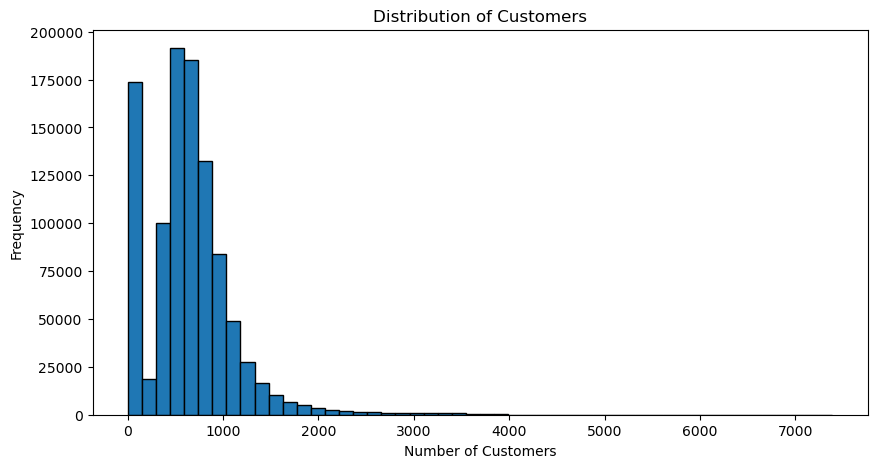

In [86]:
plt.figure(figsize=(10,5))
plt.hist(train["Customers"], bins=50, edgecolor="black")
plt.title("Distribution of Customers")
plt.xlabel("Number of Customers")
plt.ylabel("Frequency")
plt.show()

##### Observation:- The Customers variable exhibits a positively skewed distribution. Most observations are concentrated between 
##### approximately 300 and 1000 customers per day, while a small number of observations have significantly higher customer counts, 
##### resulting in a long right tail. This indicates that although the majority of stores experience
##### moderate customer traffic, a few stores receive exceptionally high numbers of customers, likely due to promotions,
##### holidays, or other business events.

In [87]:
train[["Customers", "Sales"]].corr()

,Customers,Sales
Customers,1.000000,0.894711
Sales,0.894711,1.000000


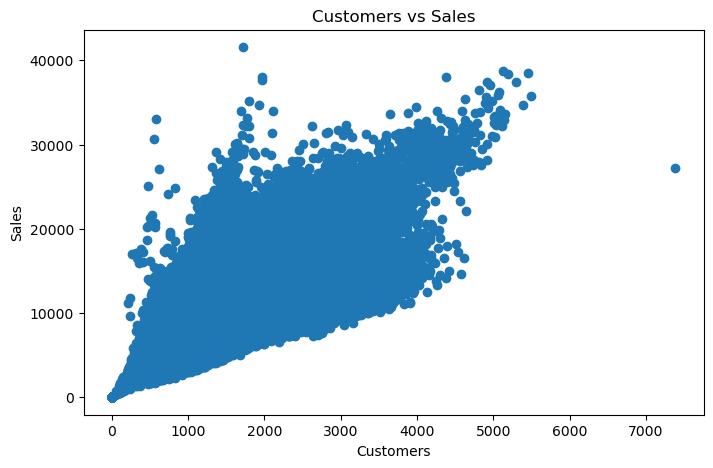

In [88]:
plt.figure(figsize=(8,5))
plt.scatter(train["Customers"], train["Sales"])
plt.xlabel("Customers")
plt.ylabel("Sales")
plt.title("Customers vs Sales")
plt.show()

#### Observation:-The scatter plot between Customers and Sales reveals a strong positive relationship.
#### As the number of customers increases, sales generally increase as well. The data points follow an upward trend,
#### indicating that customer count is a strong predictor of sales. A few outliers are present, but the overall relationship remains consistent,
#### making Customers one of the most influential features for sales prediction.

### 4. 'StateHoliday' Column Analysis

In [89]:
train['StateHoliday'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1017209 entries, 0 to 1017208
Series name: StateHoliday
Non-Null Count    Dtype 
--------------    ----- 
1017209 non-null  object
dtypes: object(1)
memory usage: 7.8+ MB


In [90]:
train['StateHoliday'].describe()

count     1017209
unique          4
top             0
freq       986159
Name: StateHoliday, dtype: object

In [91]:
train['StateHoliday'].nunique()

4

In [92]:
train['StateHoliday'].unique()

array(['0', 'a', 'b', 'c'], dtype=object)

In [93]:
train['StateHoliday'].value_counts()

StateHoliday
0    986159
a     20260
b      6690
c      4100
Name: count, dtype: int64

##### Here,

#### a = Public Holiday
#### b = Easter Holiday
#### c = Christmas Holiday
#### 0 = No holiday

In [94]:
train.groupby(["StateHoliday","Open"])[["Sales"]].mean()

Sales
StateHoliday Open             
0            0        0.000000
             1     6953.515034
a            0        0.000000
             1     8487.471182
b            0        0.000000
             1     9887.889655
c            0        0.000000
             1     9743.746479

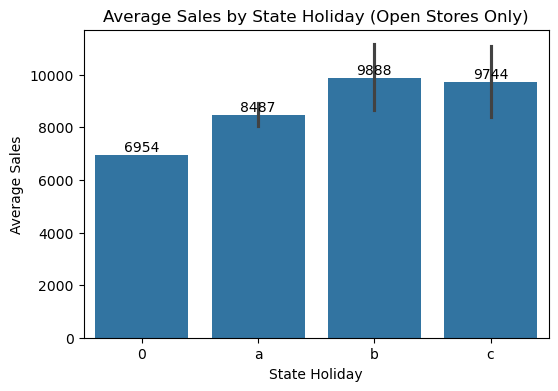

In [95]:
plt.figure(figsize=(6,4))
ax = sns.barplot(
    data=train[train["Open"] == 1],
    x="StateHoliday",
    y="Sales"
)
# Bar ke upar values
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")
plt.xlabel("State Holiday")
plt.ylabel("Average Sales")
plt.title("Average Sales by State Holiday (Open Stores Only)")
plt.show()

##### Observation:-Sales are zero whenever stores are closed (Open = 0), regardless of the holiday type. 
##### For open stores (Open = 1), average sales are significantly higher on state holidays compared to normal working days.
##### Easter holidays (b) record the highest average sales (9887.89), followed by Christmas holidays (c) and Public holidays (a).
##### This indicates that holiday periods positively influence sales for stores that remain open.

In [96]:
train.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday'],
      dtype='object')

### 5. SchoolHoliday column analysis 

In [97]:
train['SchoolHoliday'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1017209 entries, 0 to 1017208
Series name: SchoolHoliday
Non-Null Count    Dtype
--------------    -----
1017209 non-null  int64
dtypes: int64(1)
memory usage: 7.8 MB


In [98]:
train['SchoolHoliday'].describe()

count    1.017209e+06
mean     1.786467e-01
std      3.830564e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.000000e+00
Name: SchoolHoliday, dtype: float64

In [99]:
train['SchoolHoliday'].nunique()

2

In [100]:
train['SchoolHoliday'].unique()

array([1, 0])

In [101]:
train['SchoolHoliday'].value_counts()

SchoolHoliday
0    835488
1    181721
Name: count, dtype: int64

In [102]:
train.groupby(["SchoolHoliday","Open"])[["Sales"]].mean()

Sales
SchoolHoliday Open             
0             0        0.000000
              1     6896.782411
1             0        0.000000
              1     7200.181650

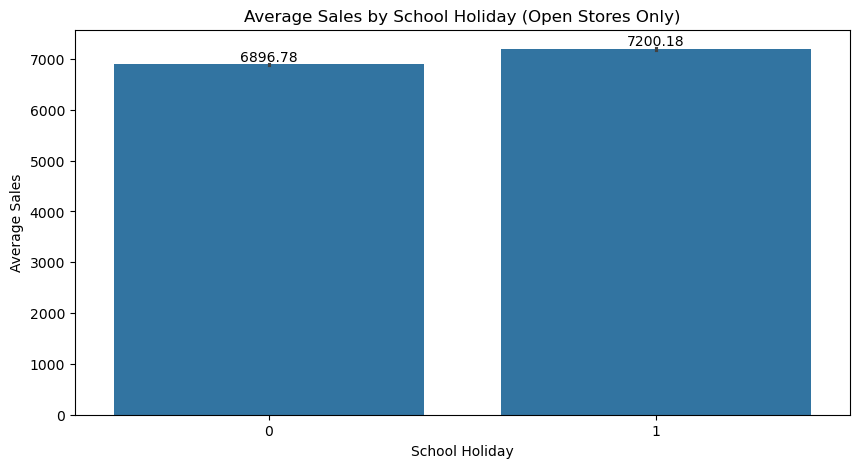

In [103]:
open_store=train[train['Open']==1]
plt.figure(figsize=(10,5))
ax=sns.barplot(data=open_store,x="SchoolHoliday",y="Sales")
for container in ax.containers:
    ax.bar_label(container)
plt.xlabel("School Holiday")
plt.ylabel("Average Sales")
plt.title("Average Sales by School Holiday (Open Stores Only)")
plt.show()

##### Observation:-Sales are zero whenever stores are closed (Open = 0). For open stores (Open = 1), 
##### the average sales during school holidays (7200.18) are slightly higher than during non-school holidays (6896.78).
##### This suggests that school holidays have a positive but moderate effect on store sales.

#### 6.'DayOfWeek' Column Analysis

In [104]:
train['DayOfWeek'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1017209 entries, 0 to 1017208
Series name: DayOfWeek
Non-Null Count    Dtype
--------------    -----
1017209 non-null  int64
dtypes: int64(1)
memory usage: 7.8 MB


In [105]:
train['DayOfWeek'].unique()

array([5, 4, 3, 2, 1, 7, 6])

In [106]:
train['DayOfWeek'].value_counts()

DayOfWeek
5    145845
4    145845
3    145665
2    145664
1    144730
7    144730
6    144730
Name: count, dtype: int64

In [107]:
train.groupby(['DayOfWeek','Open'])[["Sales"]].mean()

Sales
DayOfWeek Open             
1         0        0.000000
          1     8216.073074
2         0        0.000000
          1     7088.113656
3         0        0.000000
          1     6728.122978
4         0        0.000000
          1     6767.310159
5         0        0.000000
          1     7072.677012
6         0        0.000000
          1     5874.840238
7         0        0.000000
          1     8224.723908

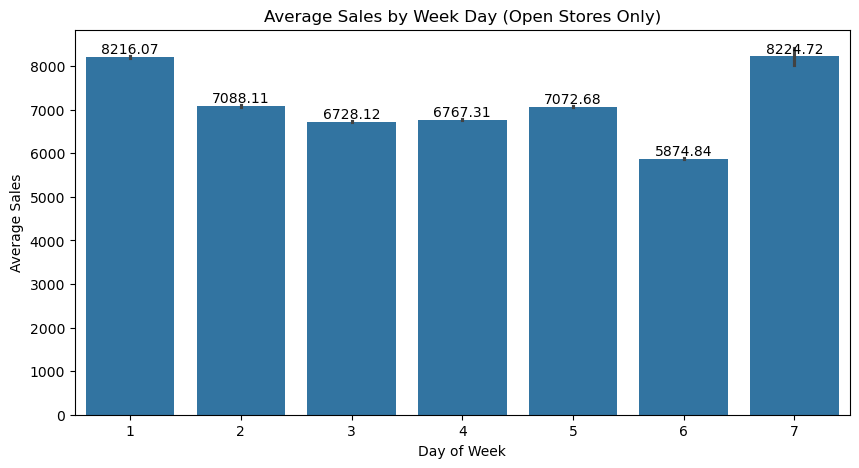

In [108]:
plt.figure(figsize=(10,5))
ax=sns.barplot(data=open_store,x="DayOfWeek",y="Sales")
for container in ax.containers:
    ax.bar_label(container)
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")
plt.title("Average Sales by Week Day (Open Stores Only)")
plt.show()

#### Observation:-
#### The analysis shows that sales are zero whenever stores are closed (Open = 0).
#### For open stores, sales vary across the days of the week. 
#### Sunday records the highest average sales (8224.72), followed closely by Monday (8216.07),
#### whereas Saturday has the lowest average sales (5874.84). 
#### This indicates that the day of the week has a significant impact on sales and
#### should be considered an important feature for sales prediction models.

In [109]:
train.groupby(["DayOfWeek","Open"])["Customers"].mean()

DayOfWeek  Open
1          0          0.000000
           1        855.444984
2          0          0.000000
           1        769.986753
3          0          0.000000
           1        740.598876
4          0          0.000000
           1        755.569784
5          0          0.000000
           1        781.771639
6          0          0.000000
           1        660.177526
7          0          0.000000
           1       1441.532424
Name: Customers, dtype: float64

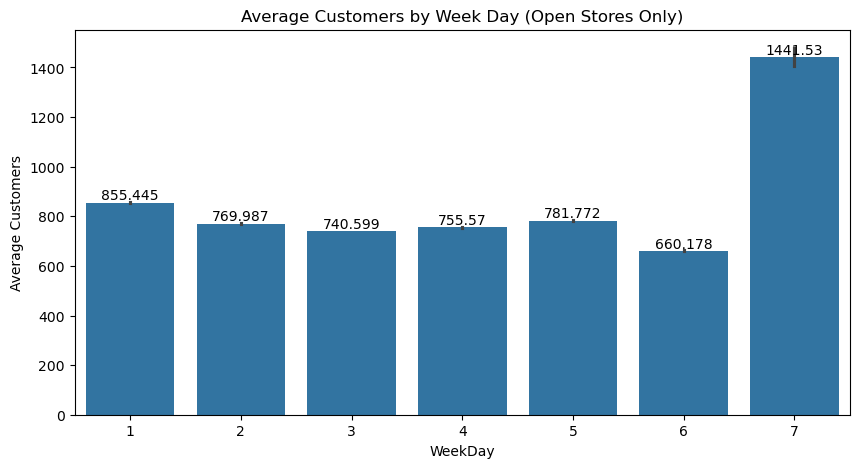

In [110]:
plt.figure(figsize=(10,5))
ax=sns.barplot(data=open_store,x="DayOfWeek",y="Customers")
for container in ax.containers:
    ax.bar_label(container)
plt.xlabel("WeekDay")
plt.ylabel("Average Customers")
plt.title("Average Customers by Week Day (Open Stores Only)")
plt.show()

In [111]:
day_open=train.groupby(["DayOfWeek","Open"])[["Store"]].count().reset_index().rename(columns={"Store":"Count"})
day_open

,DayOfWeek,Open,Count
0,1,0,7170
1,1,1,137560
2,2,0,1703
3,2,1,143961
4,3,0,3729
5,3,1,141936
6,4,0,11201
7,4,1,134644
8,5,0,7205
9,5,1,138640


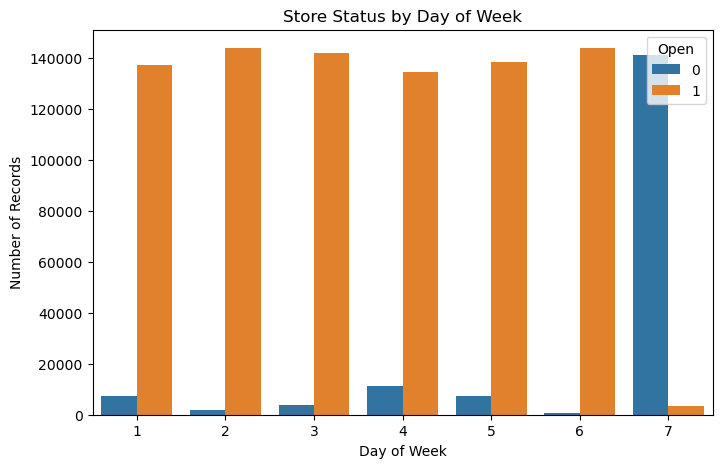

In [112]:
plt.figure(figsize=(8,5))
sns.barplot(data=day_open, x="DayOfWeek", y="Count",hue="Open")
plt.title("Store Status by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Records")
plt.show()

#### Observation:-
#### Sunday has the fewest open stores (3,593), yet it records the highest average customers (1,441.53) and the highest average sales (8,224.72).
#### This indicates that the limited number of stores operating on Sundays serve a larger customer base,leading to higher average sales per open store.

### 7. Promo Column Analysis

In [113]:
train["Promo"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1017209 entries, 0 to 1017208
Series name: Promo
Non-Null Count    Dtype
--------------    -----
1017209 non-null  int64
dtypes: int64(1)
memory usage: 7.8 MB


In [114]:
train["Promo"].nunique()

2

In [115]:
train["Promo"].unique()

array([1, 0])

In [116]:
train["Promo"].value_counts()

Promo
0    629129
1    388080
Name: count, dtype: int64

#### 0 → No promotion was active.
#### 1 → A promotion was active.
#### Promotional campaigns may include discounts, special offers, seasonal sales, price reductions
#### or marketing campaigns aimed at attracting more customers and increasing sales.

In [117]:
train.groupby(["Promo","Open"]).agg({"Sales":"mean","Customers":"mean"})

Sales   Customers
Promo Open                         
0     0        0.000000    0.000000
      1     5929.407603  696.856886
1     0        0.000000    0.000000
      1     8228.281239  844.434401

In [118]:
train.groupby("Promo").agg({"Sales":"mean","Customers":"mean"})

,Sales,Customers
Promo,,
0,4406.050805,517.823542
1,7991.152046,820.098815


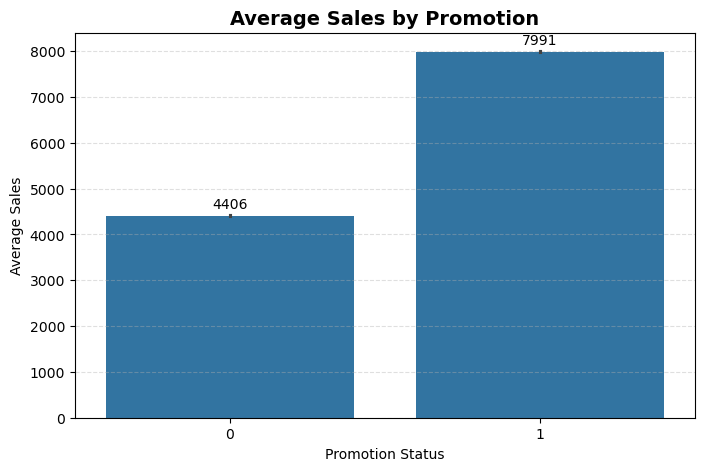

In [119]:
plt.figure(figsize=(8,5))
ax = sns.barplot(data=train, x="Promo", y="Sales")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)
plt.title("Average Sales by Promotion", fontsize=14, fontweight="bold")
plt.xlabel("Promotion Status")
plt.ylabel("Average Sales")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

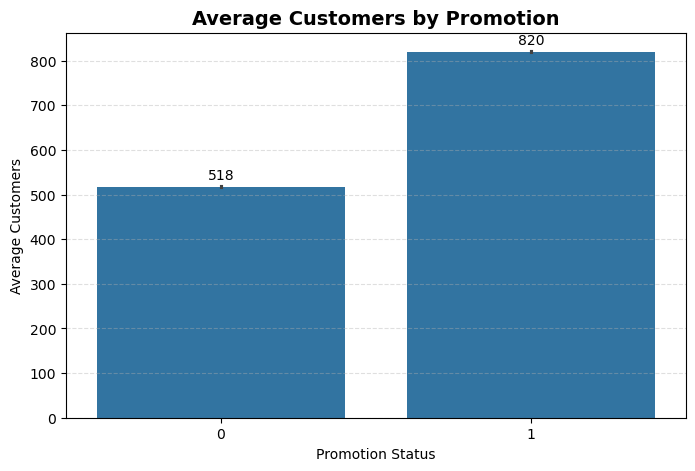

In [120]:
plt.figure(figsize=(8,5))
ax = sns.barplot(data=train, x="Promo", y="Customers")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)
plt.title("Average Customers by Promotion", fontsize=14, fontweight="bold")
plt.xlabel("Promotion Status")
plt.ylabel("Average Customers")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

#### Observation:-
#### stores running promotions not only achieve higher average sales but also attract more customers,
#### suggesting that promotional campaigns increase both customer footfall and revenue.

In [121]:
pd.crosstab(train["StateHoliday"], train["Promo"])

Promo,0,1
StateHoliday,,
0,608875,377284
a,12809,7451
b,3345,3345
c,4100,0


In [122]:
train.groupby(["StateHoliday", "Promo"])[["Sales", "Customers"]].mean()

Sales   Customers
StateHoliday Promo                         
0            0      4546.129304  533.936568
             1      8209.042228  842.064246
a            0       195.414630   33.934499
             1       454.601933   60.807811
b            0       225.705531   39.191928
             1       202.917489   33.931839
c            0       168.733171   27.174390

In [123]:
pd.crosstab(train["DayOfWeek"], train["Promo"])

Promo,0,1
DayOfWeek,,
1,66970,77760
2,68084,77580
3,68085,77580
4,68265,77580
5,68265,77580
6,144730,0
7,144730,0


#### Observation:-
#### The company primarily focuses its promotional campaigns on weekdays rather than weekends. 
#### This strategy may be based on customer shopping patterns or business policies, where regular weekday traffic is boosted through promotions
#### while weekends rely on natural customer demand.

In [124]:
pd.crosstab(train["Promo"], train["Open"])

Open,0,1
Promo,,
0,161633,467496
1,11184,376896


#### If store is closed (open=0) why Promo=1 and there are 11184 records why ?

In [125]:
train[(train["Open"]==0 )& (train["Promo"] == 1)][["Date", "StateHoliday", "SchoolHoliday", "Sales", "Customers"]].sample(n=50)

,Date,StateHoliday,SchoolHoliday,Sales,Customers
919780,2013-03-29,b,1,0,0
420770,2014-06-19,a,0,0,0
490151,2014-04-18,b,1,0,0
656803,2013-11-20,a,0,0,0
320110,2014-10-03,a,0,0,0
102040,2015-05-01,a,0,0,0
476027,2014-05-01,a,0,0,0
102559,2015-05-01,a,0,0,0
883277,2013-05-01,a,0,0,0
489868,2014-04-18,b,0,0,0


In [126]:
df=train[(train["Open"]==0 )& (train["Promo"] == 1)]
df['StateHoliday'].value_counts()

StateHoliday
a    7065
b    3295
0     824
Name: count, dtype: int64

#### Observation:-
#### Among the records where Promo = 1 and Open = 0, the majority belong to public (a) and Easter (b) holidays. 
#### This suggests that promotional events may have been scheduled during holiday periods when some stores remained closed. 
#### A small number of records (824) occur on non-holiday days, indicating other possible reasons for store closure, 
#### such as operational or regional factors.

In [127]:
df[df["StateHoliday"] == "0"]["Sales"].sum()
df[df["StateHoliday"] == "0"]["Customers"].sum()

np.int64(0)

### 8. Date Column Analysis

In [128]:
train["Date"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1017209 entries, 0 to 1017208
Series name: Date
Non-Null Count    Dtype 
--------------    ----- 
1017209 non-null  object
dtypes: object(1)
memory usage: 7.8+ MB


In [129]:
train["Date"] = pd.to_datetime(train["Date"])

In [130]:
train["Date"].dtype

dtype('<M8[ns]')

In [131]:
train["Date"].min()

Timestamp('2013-01-01 00:00:00')

In [132]:
train["Date"].max()

Timestamp('2015-07-31 00:00:00')

In [133]:
train["Date"].head()

0   2015-07-31
1   2015-07-31
2   2015-07-31
3   2015-07-31
4   2015-07-31
Name: Date, dtype: datetime64[ns]

In [134]:
train["Date"].tail()

1017204   2013-01-01
1017205   2013-01-01
1017206   2013-01-01
1017207   2013-01-01
1017208   2013-01-01
Name: Date, dtype: datetime64[ns]

In [135]:
train["Year"]=train["Date"].dt.year
train["Year"].value_counts()

Year
2013    406974
2014    373855
2015    236380
Name: count, dtype: int64

In [136]:
train["Month"]=train["Date"].dt.month
train["Month"].value_counts().sort_index()

Month
1     103694
2      93660
3     103695
4     100350
5     103695
6     100350
7      98115
8      63550
9      61500
10     63550
11     61500
12     63550
Name: count, dtype: int64

In [137]:
train["Day"]=train["Date"].dt.day
train["Day"].value_counts().sort_index()

Day
1     33484
2     33485
3     33485
4     33485
5     33485
6     33485
7     33485
8     33485
9     33485
10    33485
11    33485
12    33485
13    33485
14    33485
15    33485
16    33485
17    33485
18    33485
19    33485
20    33485
21    33485
22    33485
23    33485
24    33485
25    33485
26    33485
27    33485
28    33485
29    30140
30    30140
31    19350
Name: count, dtype: int64

In [138]:
train["Quarter"] = train["Date"].dt.quarter
train["Quarter"].value_counts()

Quarter
2    304395
1    301049
3    223165
4    188600
Name: count, dtype: int64

#### Now we have 4 new columns Year Month Quarter and day

### 9. Year wise Analysis

In [139]:
train[train["Open"] == 1].groupby("Year")[["Sales", "Customers"]].mean()

,Sales,Customers
Year,,
2013,6814.392025,757.537292
2014,7025.404201,774.728739
2015,7088.126648,752.674864


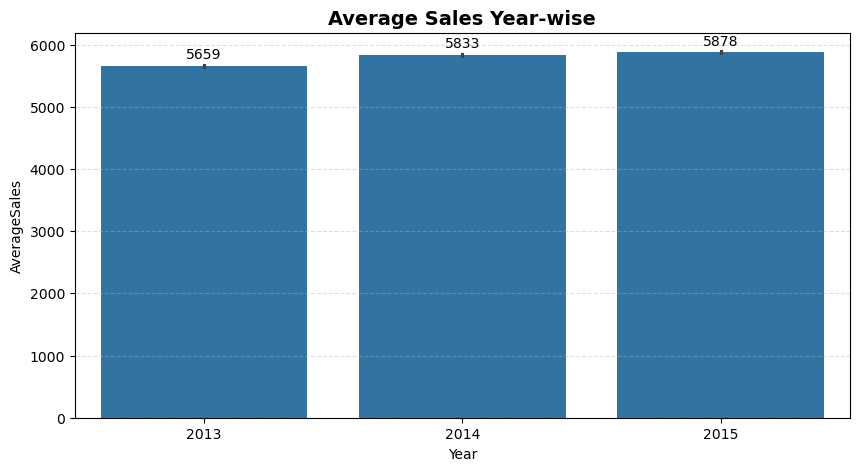

In [147]:
plt.figure(figsize=(10,5))
ax=sns.barplot(data=train,x="Year",y="Sales")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)
plt.title("Average Sales Year-wise", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("AverageSales")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

#### Observation:-
#### Average sales show a slight upward trend from 2013 to 2015. 
#### The proportion of open and closed stores remains nearly constant across all three years, 
#### indicating that the increase in sales is unlikely to be caused by differences in store closures.

In [141]:
pd.crosstab(train["Year"], train["Open"])

Open,0,1
Year,,
2013,69031,337943
2014,63438,310417
2015,40348,196032


### 10 Month wise Analysis

In [142]:
train['Month'].value_counts().sort_index()

Month
1     103694
2      93660
3     103695
4     100350
5     103695
6     100350
7      98115
8      63550
9      61500
10     63550
11     61500
12     63550
Name: count, dtype: int64

In [143]:
pd.crosstab(train["Month"],train["Open"])

Open,0,1
Month,,
1,17351,86343
2,13417,80243
3,17715,85980
4,18619,81731
5,23592,80103
6,17774,82576
7,12528,85587
8,9137,54413
9,9170,52330


In [144]:
train.groupby("Month")[["Sales","Customers"]].mean()

,Sales,Customers
Month,,
1,5465.395529,601.617172
2,5645.253150,626.715129
3,5784.578871,629.401958
4,5738.866916,630.612945
5,5489.639973,601.991263
6,5760.964375,624.794091
7,6064.915711,656.629781
8,5693.016554,642.496979
9,5570.246033,634.438699


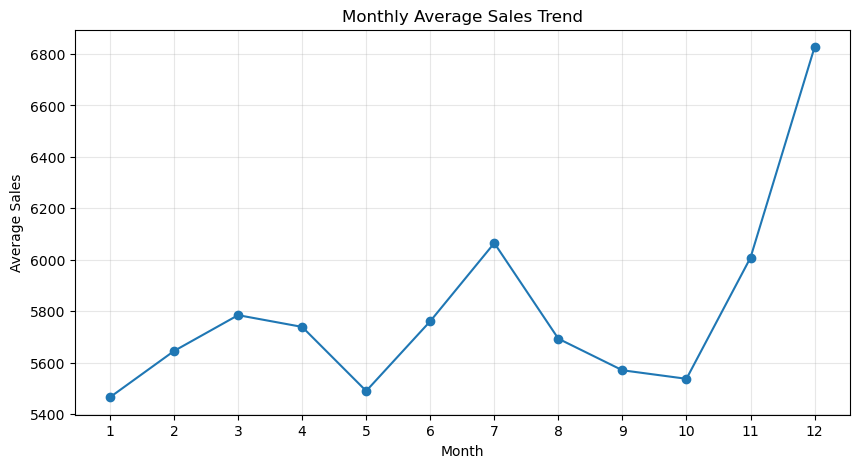

In [145]:
monthly_sales = train.groupby("Month")["Sales"].mean()
plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.xticks(range(1,13))
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.title("Monthly Average Sales Trend")
plt.grid(alpha=0.3)
plt.show()

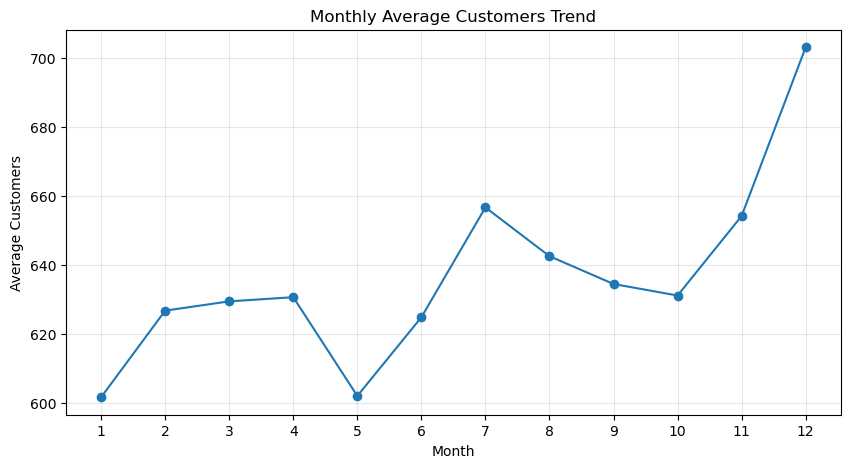

In [146]:
monthly_customers = train.groupby("Month")["Customers"].mean()
plt.figure(figsize=(10,5))
plt.plot(monthly_customers.index, monthly_customers.values, marker="o")
plt.xticks(range(1,13))
plt.xlabel("Month")
plt.ylabel("Average Customers")
plt.title("Monthly Average Customers Trend")
plt.grid(alpha=0.3)
plt.show()

#### Observation:
#### 1.December has the highest average sales (6826.61) and customer count (703.07), indicating strong seasonal demand.
#### 2.Sales and customer footfall show similar monthly trends, suggesting a positive relationship between customer traffic and sales.
#### 3.The variation in monthly sales indicates the presence of seasonality, making Month an important feature for forecasting future sales.

In [151]:
train[train['Promo']==1]
train[train['Promo']==1].groupby(['Year','Month'])[['Promo']].count()

Promo
Year Month       
2013 1      11150
     2      11150
     3      16725
     4      13380
     5      14495
     6      11150
     7      14495
     8      13380
     9      11150
     10     11150
     11     11150
     12     11150
2014 1      11150
     2      11150
     3      12265
     4      13380
     5      13380
     6      12265
     7      12155
     8      10285
     9      11220
     10     12155
     11     14025
     12      9350
2015 1      16725
     2      11150
     3      13380
     4      13380
     5      12265
     6      13380
     7      14495

In [152]:
train.groupby(['Year','Month'])[['Sales']].mean()

Sales
Year Month             
2013 1      5211.555578
     2      5494.371397
     3      5820.349168
     4      5483.749836
     5      5364.127383
     6      5402.162960
     7      6042.062260
     8      5729.574049
     9      5322.988430
     10     5429.258788
     11     5864.601614
     12     6703.618140
2014 1      5431.875799
     2      5731.091512
     3      5584.257312
     4      5815.993333
     5      5632.670534
     6      5681.526188
     7      5999.403381
     8      5649.421252
     9      5865.104029
     10     5665.564878
     11     6179.249661
     12     6973.282456
2015 1      5752.747866
     2      5710.296541
     3      5949.130132
     4      5916.857578
     5      5472.122002
     6      6199.203976
     7      6142.705511

In [153]:
train.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'Year', 'Month', 'Day', 'Quarter'],
      dtype='object')

### 11. Quarter wise Analysis

In [154]:
train['Quarter'].value_counts().sort_index()

Quarter
1    301049
2    304395
3    223165
4    188600
Name: count, dtype: int64

In [155]:
pd.crosstab(train['Quarter'],train['Open'])

Open,0,1
Quarter,,
1,48483,252566
2,59985,244410
3,30835,192330
4,33514,155086


In [158]:
train.groupby(["Quarter",'Open'])[["Sales","Customers"]].mean()

Sales   Customers
Quarter Open                         
1       0        0.000000    0.000000
        1     6712.285264  737.819287
2       0        0.000000    0.000000
        1     7050.678315  770.850538
3       0        0.000000    0.000000
        1     6756.203078  750.137233
4       0        0.000000    0.000000
        1     7448.826832  806.108965

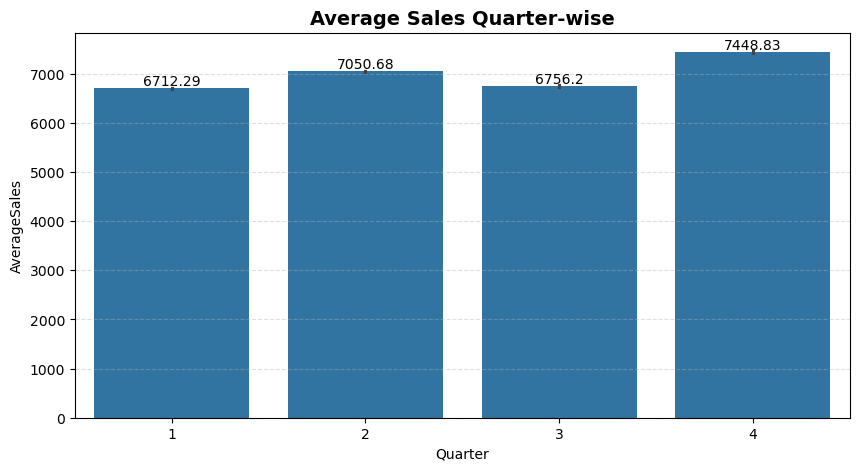

In [166]:
plt.figure(figsize=(10,5))
ax=sns.barplot(data=train[train['Open']==1],x='Quarter',y='Sales')
for container in ax.containers:
    ax.bar_label(container)
plt.title("Average Sales Quarter-wise", fontsize=14, fontweight="bold")
plt.xlabel("Quarter")
plt.ylabel("AverageSales")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

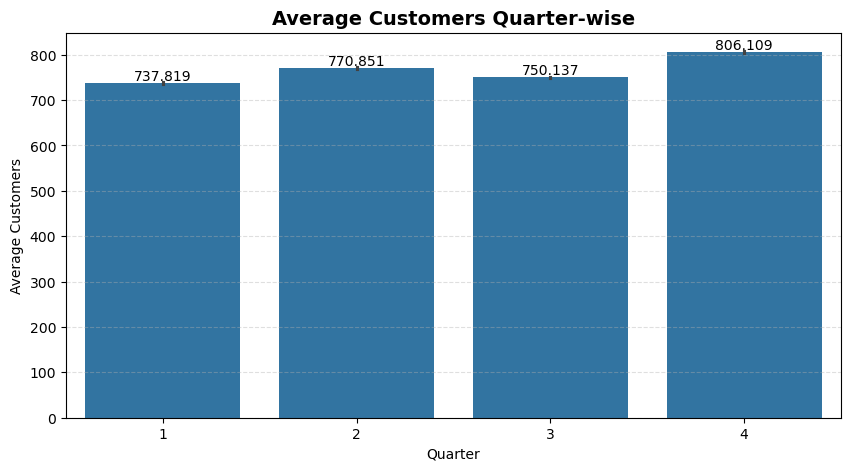

In [175]:
plt.figure(figsize=(10,5))
ax=sns.barplot(data=train[train['Open']==1],x='Quarter',y='Customers')
for container in ax.containers:
    ax.bar_label(container)
plt.title("Average Customers Quarter-wise", fontsize=14, fontweight="bold")
plt.xlabel("Quarter")
plt.ylabel("Average Customers")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

### 12. Day-Wise Analysis

In [165]:
train['Day'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1017209 entries, 0 to 1017208
Series name: Day
Non-Null Count    Dtype
--------------    -----
1017209 non-null  int32
dtypes: int32(1)
memory usage: 3.9 MB


In [168]:
train.groupby('Day')[['Sales','Customers']].mean()

,Sales,Customers
Day,,
1,4658.450603,489.512603
2,6973.664895,735.431686
3,5811.044109,612.213499
4,6818.008362,720.971181
5,6357.150246,675.477199
6,5886.054621,641.164611
7,6014.050679,657.440197
8,5665.783784,632.294848
9,5253.768165,590.616067


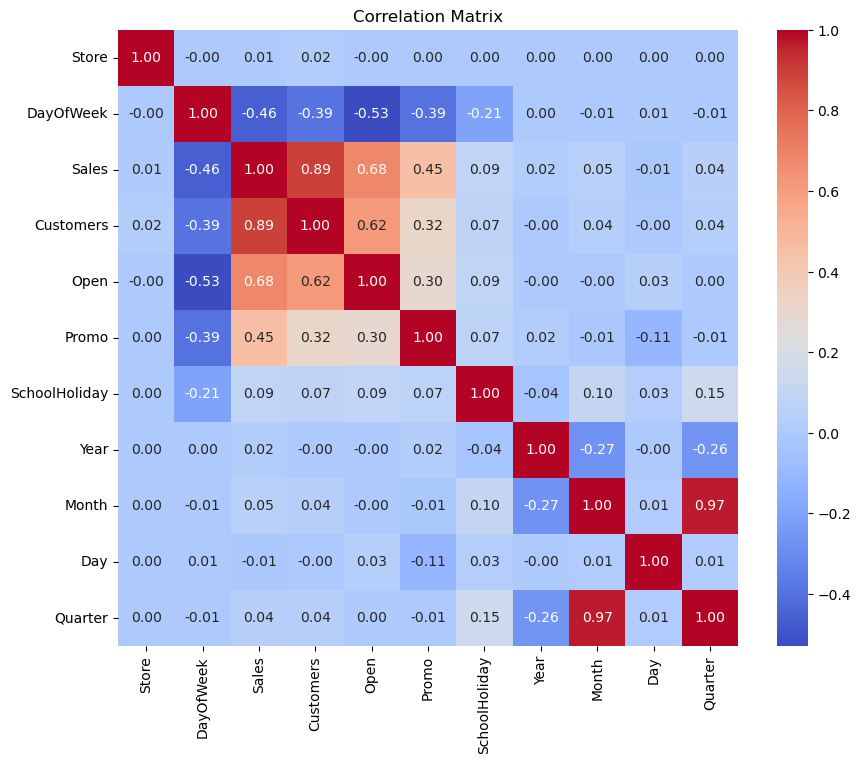

In [169]:
plt.figure(figsize=(10,8))
corr = train.corr(numeric_only=True)
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

In [172]:
corr["Sales"].sort_values(ascending=False)

Sales            1.000000
Customers        0.894711
Open             0.678472
Promo            0.452345
SchoolHoliday    0.085124
Month            0.048768
Quarter          0.043984
Year             0.023519
Store            0.005126
Day             -0.011612
DayOfWeek       -0.462125
Name: Sales, dtype: float64

#### Observation:-
#### The correlation analysis shows that Customers (0.895), Open (0.678), and Promo (0.452) have the strongest positive relationship with Sales,
#### while DayOfWeek (-0.462) has a moderate negative correlation. Features such as SchoolHoliday, Month, Quarter, Year, Store, and Day exhibit
#### weak linear correlations with Sales.

# 📌 Overall EDA Summary

## Dataset Overview

- The dataset contains over **1 million historical daily sales records** of Rossmann stores from **2013 to 2015**.
- No major data quality issues were observed, making the dataset suitable for further analysis and predictive modeling.

---

## Key Findings

- Sales distribution is positively skewed with several high-value outliers, while closed stores consistently record zero sales.
- Customer footfall is the strongest driver of sales, indicating a strong positive relationship between **Customers** and **Sales**.
- Promotional campaigns significantly increase both average sales and customer count, demonstrating their effectiveness in improving store performance.
- State Holidays and School Holidays influence store operations differently, with many stores remaining closed during State Holidays.
- Weekly analysis revealed that although very few stores remain open on **Sunday**, those stores achieve the highest average sales and customer count.
- Monthly analysis showed clear seasonality, with **December** recording the highest average sales and customer traffic, followed by **November** and **July**.
- Correlation analysis indicates that **Customers**, **Open**, and **Promo** are the most influential variables affecting sales, while **DayOfWeek** has a moderate negative relationship with Sales.

---

## Business Insights

- Customer footfall is the primary contributor to store revenue.
- Promotional campaigns effectively increase both customer visits and sales.
- Seasonal demand significantly impacts sales, particularly during the year-end months.
- Store operational status directly affects revenue generation since closed stores record zero sales.
- Retailers can leverage these insights to optimize promotional campaigns, staffing, inventory planning, and business operations.

---

## Machine Learning Insights

- Customers, Open, Promo, DayOfWeek, and seasonal features appear to be important predictors for sales forecasting.
- Features with weak linear correlation should not be removed immediately, as tree-based algorithms such as **Random Forest** and **XGBoost** can effectively capture non-linear relationships and feature interactions.
- The insights obtained during EDA will guide feature engineering and improve the predictive performance of the regression models.

---

## Conclusion

The exploratory data analysis successfully identified the major factors influencing retail sales and uncovered meaningful business patterns within the dataset. The analysis establishes a strong foundation for the next stages of the project, including **Store Dataset Analysis**, **Merged Dataset EDA**, **Feature Engineering**, **Model Development**, and **AI-based Sales Forecasting**.

---

## Next Step

➡️ Analyze **store.csv**, merge both datasets, perform feature engineering, and build machine learning regression models for accurate retail sales forecasting.